In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('Tweets.csv')
df.head()

,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)


In [2]:
df.columns

Index(['tweet_id', 'airline_sentiment', 'airline_sentiment_confidence',
       'negativereason', 'negativereason_confidence', 'airline',
       'airline_sentiment_gold', 'name', 'negativereason_gold',
       'retweet_count', 'text', 'tweet_coord', 'tweet_created',
       'tweet_location', 'user_timezone'],
      dtype='str')

In [3]:
df.shape

(14640, 15)

In [4]:
df.isnull().sum()

tweet_id                            0
airline_sentiment                   0
airline_sentiment_confidence        0
negativereason                   5462
negativereason_confidence        4118
airline                             0
airline_sentiment_gold          14600
name                                0
negativereason_gold             14608
retweet_count                       0
text                                0
tweet_coord                     13621
tweet_created                       0
tweet_location                   4733
user_timezone                    4820
dtype: int64

In [5]:
df.duplicated().sum()

np.int64(36)

In [6]:
df = df[['airline_sentiment', 'airline', 'text', 'negativereason', 'retweet_count', 'tweet_created']]
df.head()

,airline_sentiment,airline,text,negativereason,retweet_count,tweet_created
0,neutral,Virgin America,@VirginAmerica What @dhepburn said.,NaN,0,2015-02-24 11:35:52 -0800
1,positive,Virgin America,@VirginAmerica plus you've added commercials t...,NaN,0,2015-02-24 11:15:59 -0800
2,neutral,Virgin America,@VirginAmerica I didn't today... Must mean I n...,NaN,0,2015-02-24 11:15:48 -0800
3,negative,Virgin America,@VirginAmerica it's really aggressive to blast...,Bad Flight,0,2015-02-24 11:15:36 -0800
4,negative,Virgin America,@VirginAmerica and it's a really big bad thing...,Can't Tell,0,2015-02-24 11:14:45 -0800


In [7]:
df.shape

(14640, 6)

In [8]:
df.isnull().sum()

airline_sentiment       0
airline                 0
text                    0
negativereason       5462
retweet_count           0
tweet_created           0
dtype: int64

In [9]:
df.shape

(14640, 6)

In [10]:
df.duplicated().sum()

np.int64(108)

In [11]:
df = df.drop_duplicates()
df.shape

(14532, 6)

In [12]:
df['airline_sentiment'].value_counts()

airline_sentiment
negative    9118
neutral     3074
positive    2340
Name: count, dtype: int64

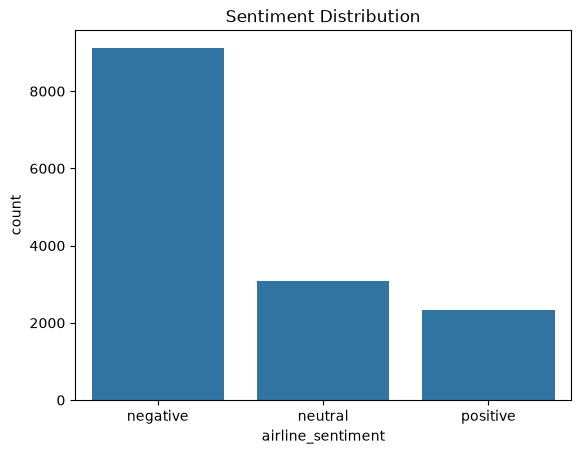

In [13]:
sns.countplot(data=df, x='airline_sentiment', order=['negative','neutral','positive'])
plt.title('Sentiment Distribution')
plt.show()

In [14]:
df[df['airline_sentiment']=='negative']['airline'].value_counts()

airline
United            2633
US Airways        2263
American          1900
Southwest         1186
Delta              955
Virgin America     181
Name: count, dtype: int64

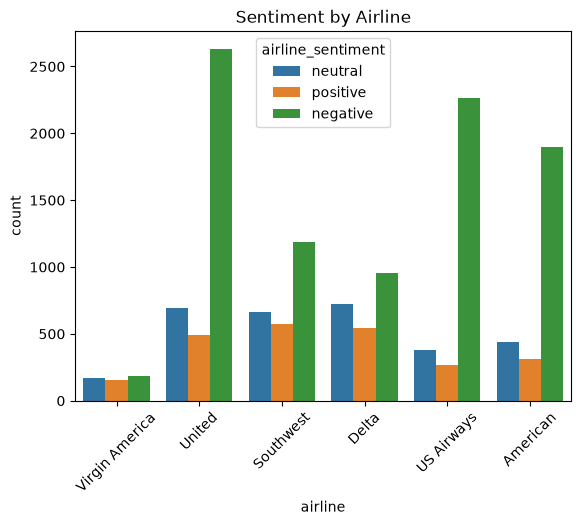

In [15]:
sns.countplot(data=df, x='airline', hue='airline_sentiment')
plt.xticks(rotation=45)
plt.title('Sentiment by Airline')
plt.show()

In [16]:
df['negativereason'].value_counts()

negativereason
Customer Service Issue         2891
Late Flight                    1655
Can't Tell                     1186
Cancelled Flight                835
Lost Luggage                    719
Bad Flight                      578
Flight Booking Problems         527
Flight Attendant Complaints     476
longlines                       177
Damaged Luggage                  74
Name: count, dtype: int64

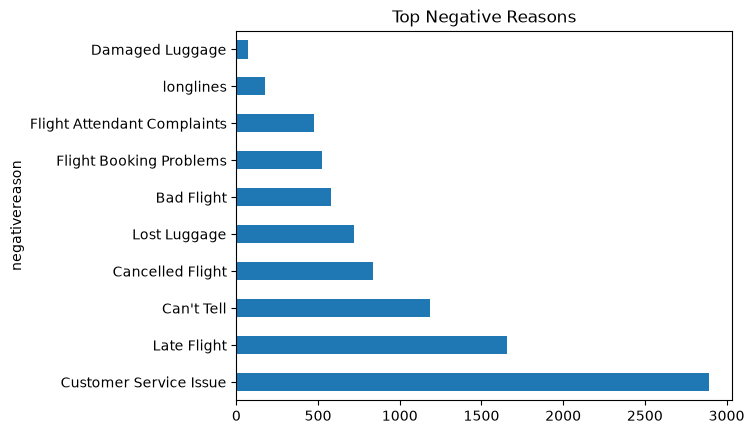

In [17]:
df['negativereason'].value_counts().plot(kind='barh')
plt.title('Top Negative Reasons')
plt.show()


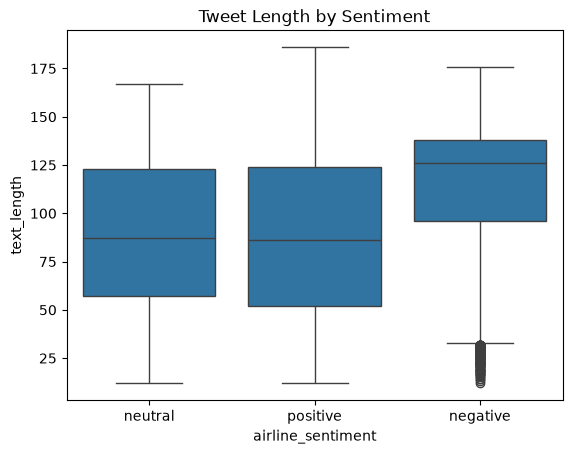

In [18]:
df['text_length'] = df['text'].apply(len)
sns.boxplot(data=df, x='airline_sentiment', y='text_length')
plt.title('Tweet Length by Sentiment')
plt.show()

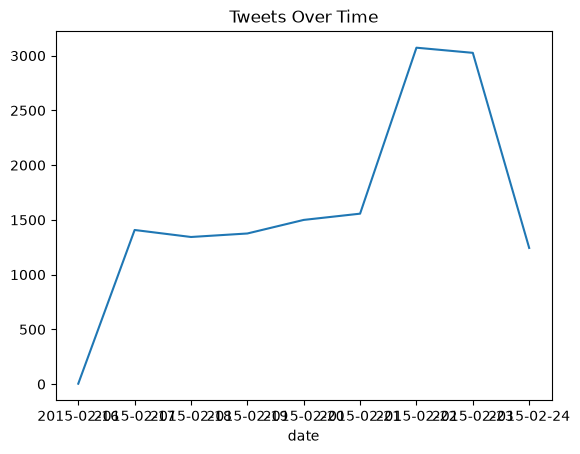

In [19]:
df['tweet_created'] = pd.to_datetime(df['tweet_created'])
df['date'] = df['tweet_created'].dt.date
df.groupby('date')['airline_sentiment'].count().plot()
plt.title('Tweets Over Time')
plt.show()

## Findings

1. **Sentiment Distribution:** Total 14,532 tweets mein se 9,118 (63%) negative hain, 3,074 (21%) neutral hain, aur 2,340 (16%) positive hain. Overall sentiment kaafi negative-heavy hai.

2. **Airline-wise Negative Tweets:** United Airlines ko sabse zyada negative tweets mile (2,633), phir US Airways (2,263) aur American (1,900). Virgin America sabse kam (181) — ho sakta hai unka total tweet volume hi kam ho.

3. **Common Negative Reason:** Sabse bada complaint "Customer Service Issue" hai (2,891 tweets), phir "Late Flight" (1,655). Ye dikhata hai ki customers ko sabse zyada dikkat staff/service response se hai, na ki sirf delays se.

4. **Tweet Length vs Sentiment:** Negative tweets ka median length (~125 characters) positive/neutral tweets (~87 characters) se zyada hai. Log jab complain karte hain to zyada detail mein likhte hain.

5. **Time Trend:** Tweets ki count 20-22 Feb 2015 ke around sabse zyada thi (3000+ per day), jo shayad kisi specific event ya issue ki wajah se ho sakta hai.

6. **Data Issues:** 108 duplicate rows the jo hata diye gaye. `negativereason` column mein 5,462 missing values hain, jo normal hai kyunki wo sirf negative tweets ke liye applicable hai.